<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_YB_WEEK_09_2_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/code/ash316/eda-to-prediction-dietanic

위 캐글을 필사

# Part1: Exploratory Data Analysis(EDA)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data=pd.read_csv('/content/drive/MyDrive/YB_data/Kaggle_EDA To Prediction(DieTanic)/train.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.isnull().sum() # checking for total null values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age, Cabin, Embarked 변수에 결측치 있음

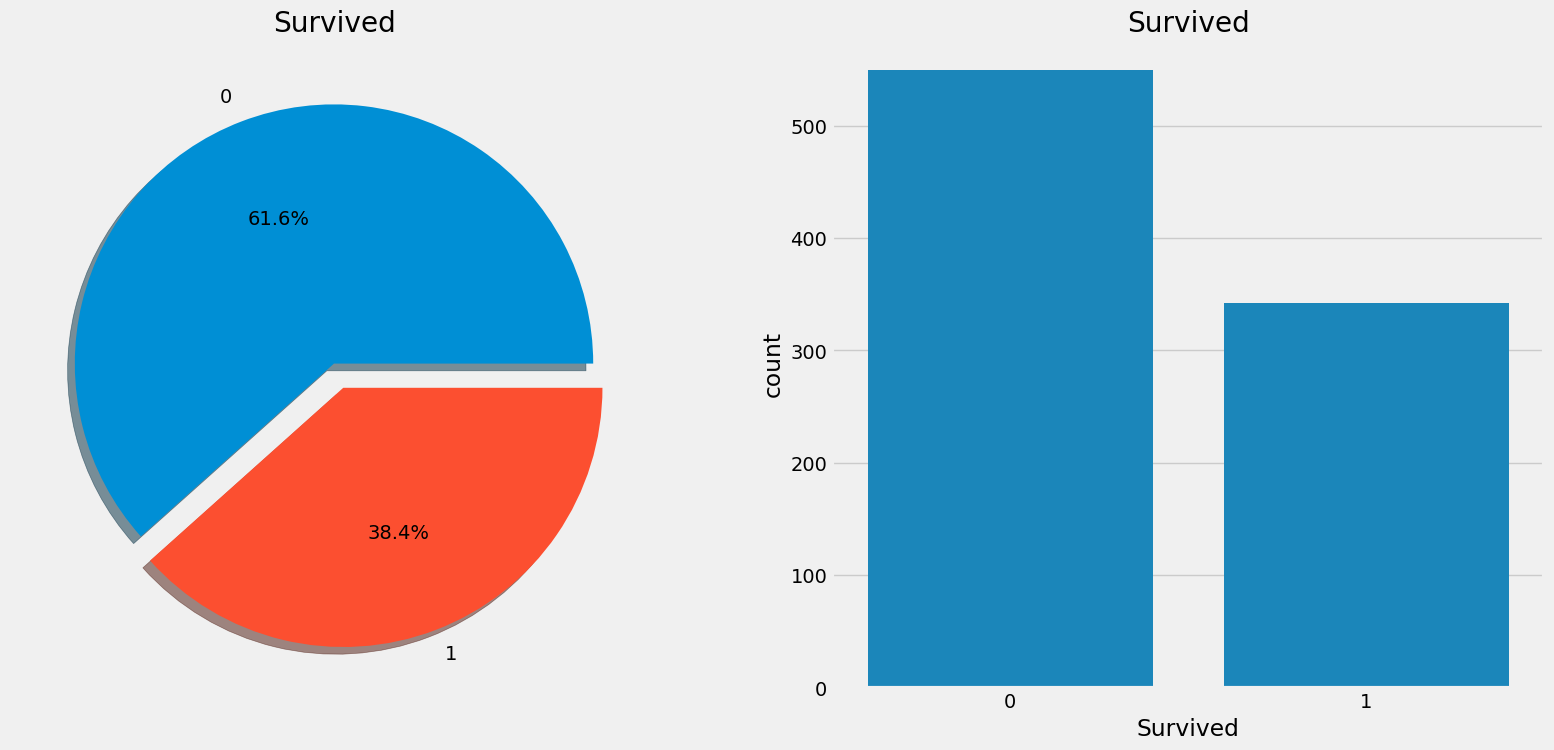

In [5]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived',data=data,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

변수
- 범주형 변수 : 두 개 이상의 범주를 가지며, 순서가 없음 ex) 성별(Sex), 승선 항구(Embarked)

- 순서형 변수 : 범주형과 비슷하지만 값들 사이에 순서/서열이 존재 ex) 객실 등급(PClass)

- 연속형 변수 : 최소값과 최대값 사이에서 연속적인 값을 가질 수 있음 ex) 나이 (Age)

## Analysing The Features

### Sex--> Categorical Feature

In [6]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

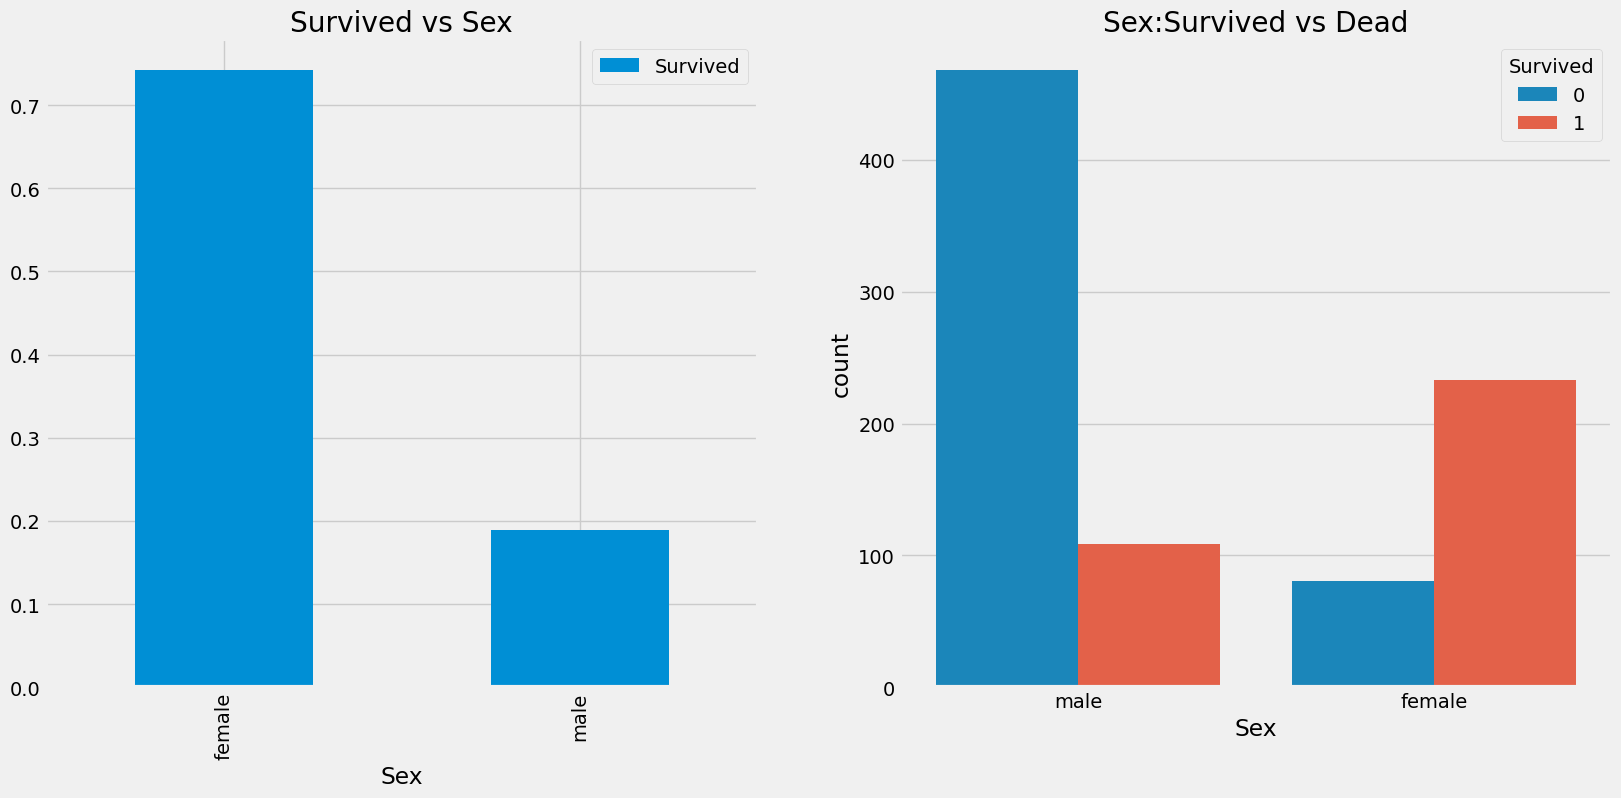

In [7]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

- 배에 탑승한 남성은 여성보다 훨씬 많음

- but 생존한 여성 수는 남성 생존자 수의 거의 두 배

- 여성의 생존률은 약 75%, 남성은 약 18~19%에 불과

- 성별(Sex) 변수는 모델링에서 매우 중요한 특징으로 보임

- but, 이것이 important feature 인지 다른 변수들도 확인해봐야 함


### Pclass --> Ordinal Feature

In [8]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


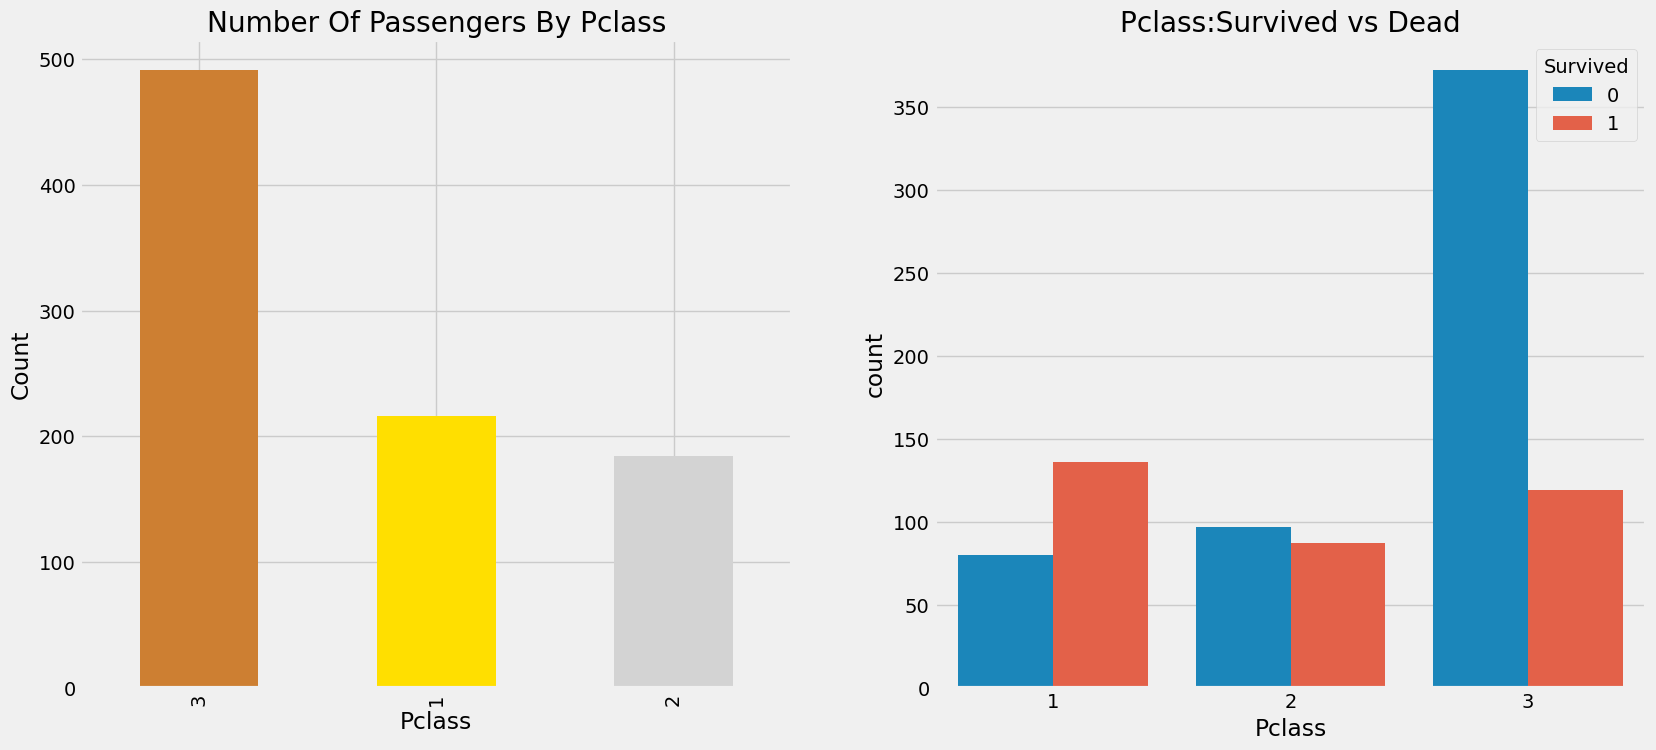

In [9]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

- 돈과 사회적 지위가 생존에 큰 영향을 미침

In [10]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

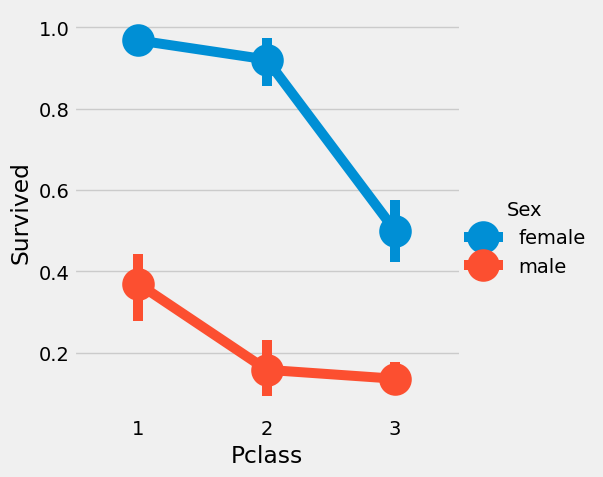

In [11]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',data=data, kind='point')
plt.show()

- FactorPlot → 범주형 변수들을 구분하기에 용이

- 객실 등급(Pclass)과 상관없이 여성은 구조 과정에서 최우선으로 고려

- Pclass 역시 중요한 특징 변수임을 확인

### Age--> Continous Feature

In [12]:
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


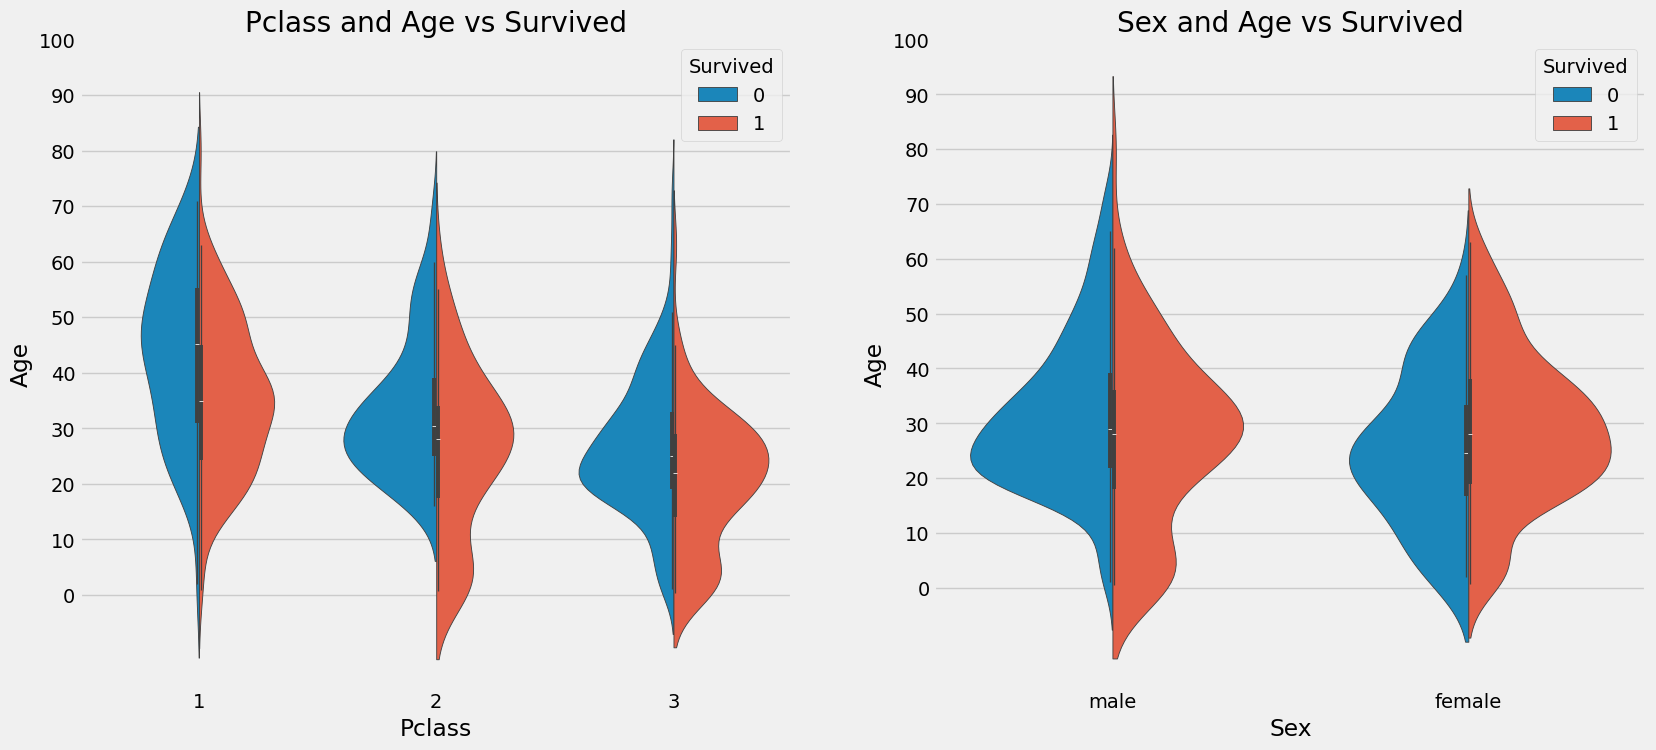

In [13]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=data,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age", hue="Survived", data=data,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

- Age에는 177개의 결측치(NaN) 있음

- 평균 나이(29세)를 결측치에 채워 넣는 것은 부적절 -> 호칭(Mr,Mrs)별 평균 나이를 계산해, 해당 그룹의 결측치를 채워 넣을 수 있음

In [14]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

- 정규표현식(Regex) [A-Za-z]+) 를 사용

- 표현식은 A~Z 또는 a~z 사이의 문자열을 찾고, 그 뒤에 점(.)이 오는 패턴을 탐색

- 이를 통해 Name 변수에서 호칭(Mr, Mrs, Miss 등)을 성공적으로 추출할 수 있음

In [15]:
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


이름에서 추출한 호칭(Initials) 중 일부는 잘못 표기된 경우가 있음 (ex. Mlle 또는 Mme → 실제로는 Miss를 의미)

-> 이런 잘못된 표기를 Miss로 교체하고, 다른 값들도 같은 방식으로 정리

In [16]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [17]:
data.groupby('Initial')['Age'].mean() #lets check the average age by Initials

,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


#### Filling NaN Ages

In [18]:
## Assigning the NaN Values with the Ceil values of the mean ages
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

In [19]:
data.Age.isnull().any() #So no null values left finally

np.False_

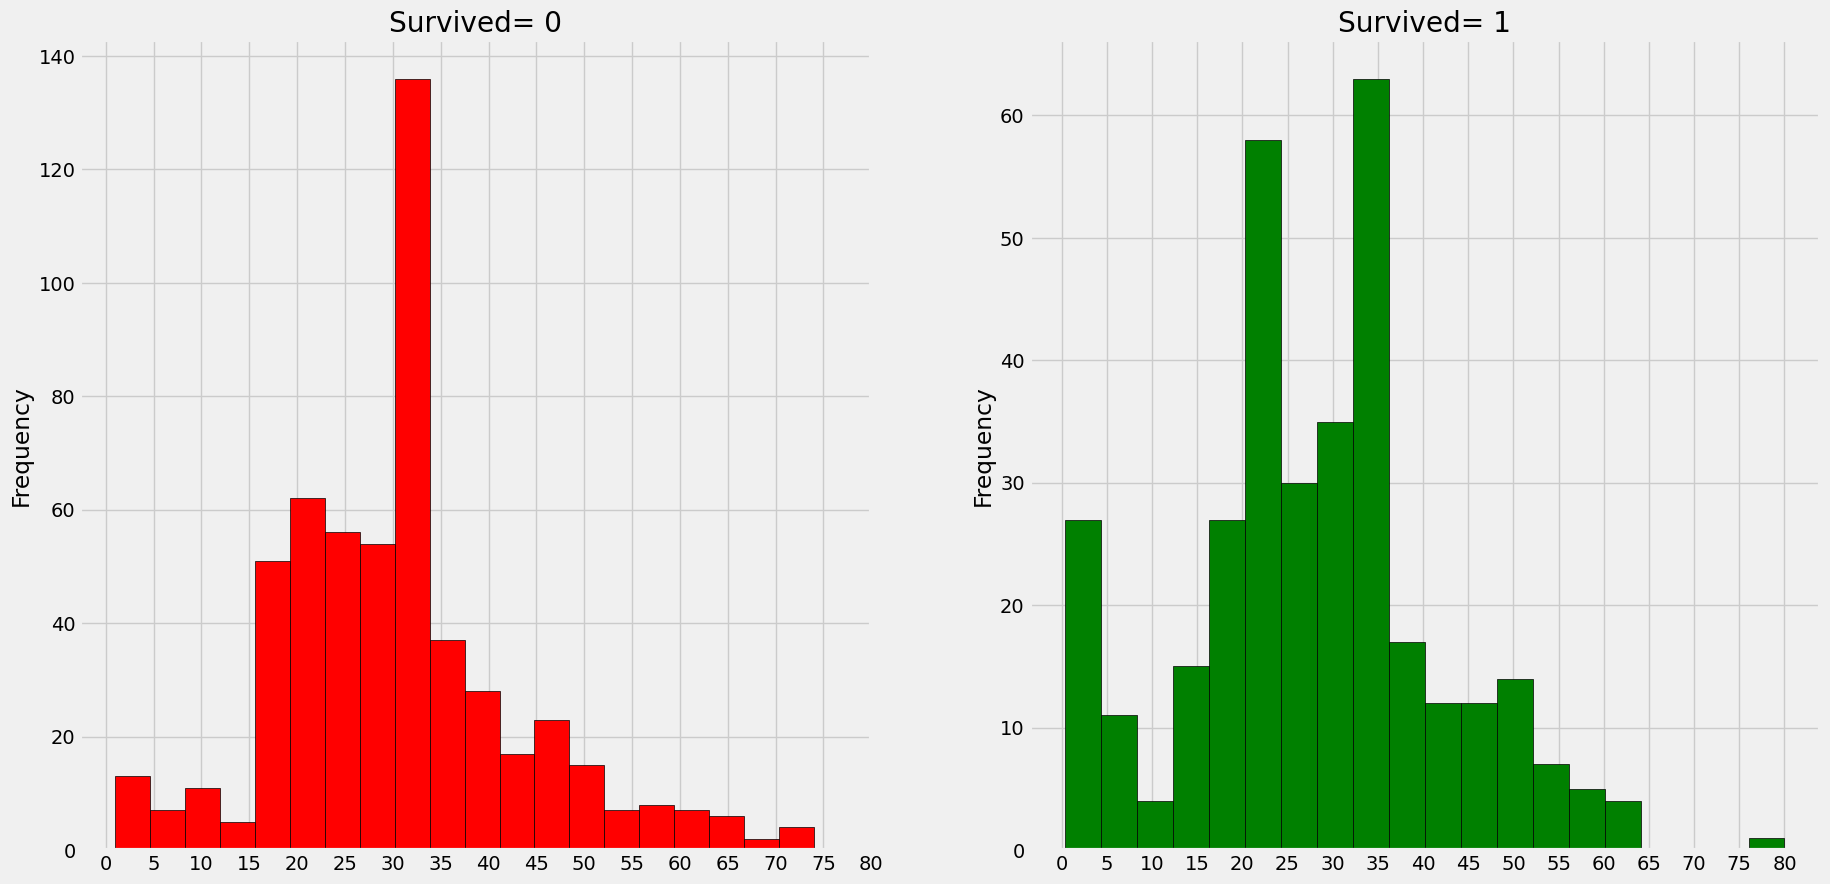

In [20]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

연령대별 생존 패턴이 뚜렷하게 나타남

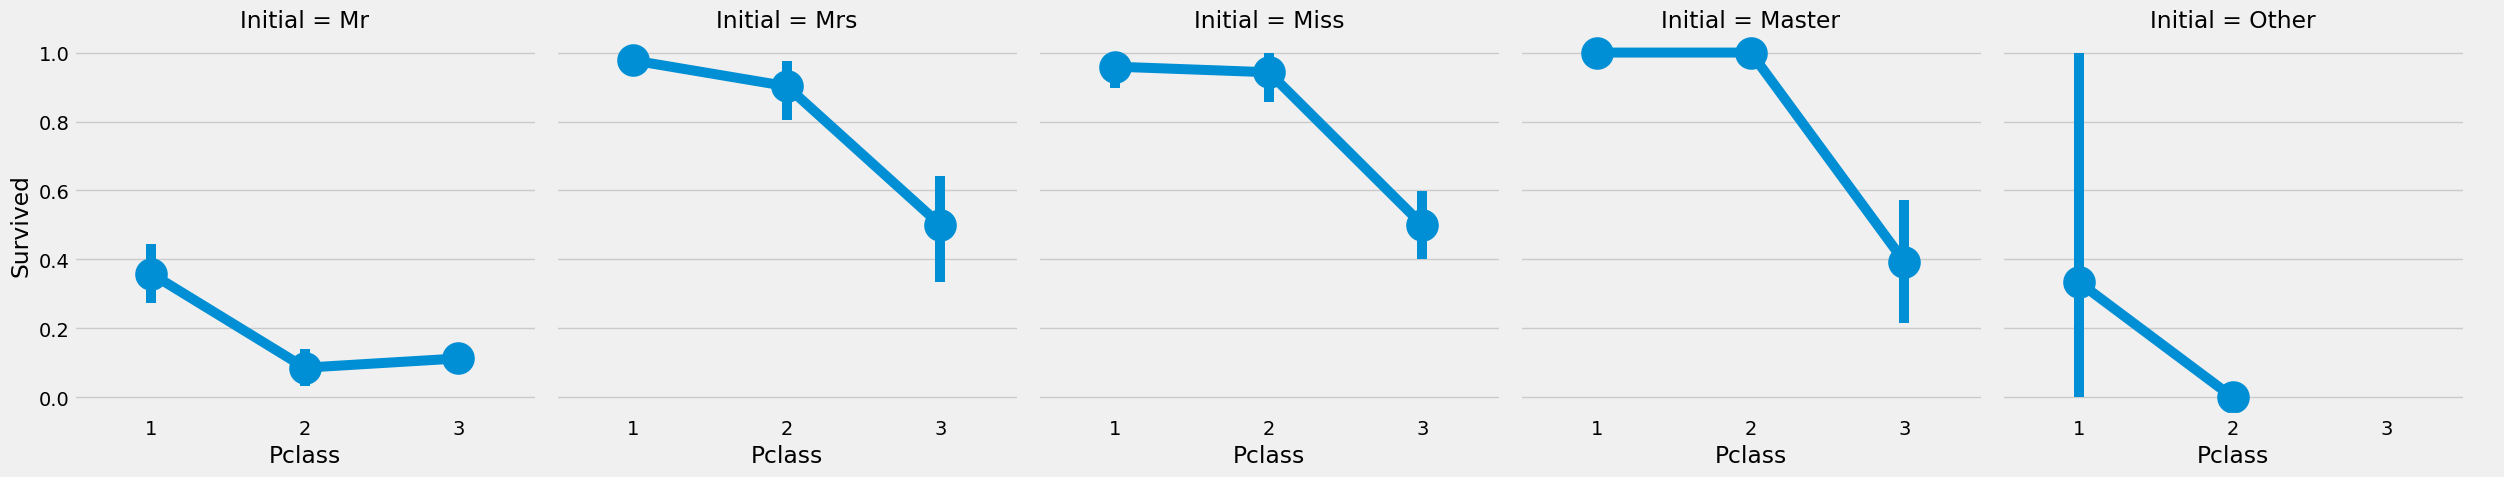

In [21]:
sns.catplot(x='Pclass',y='Survived',col='Initial',data=data, kind='point')
plt.show()

### Embarked--> Categorical Value

In [22]:
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

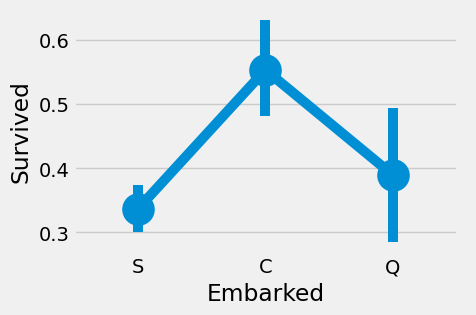

In [23]:
sns.catplot(x='Embarked',y='Survived',data=data, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

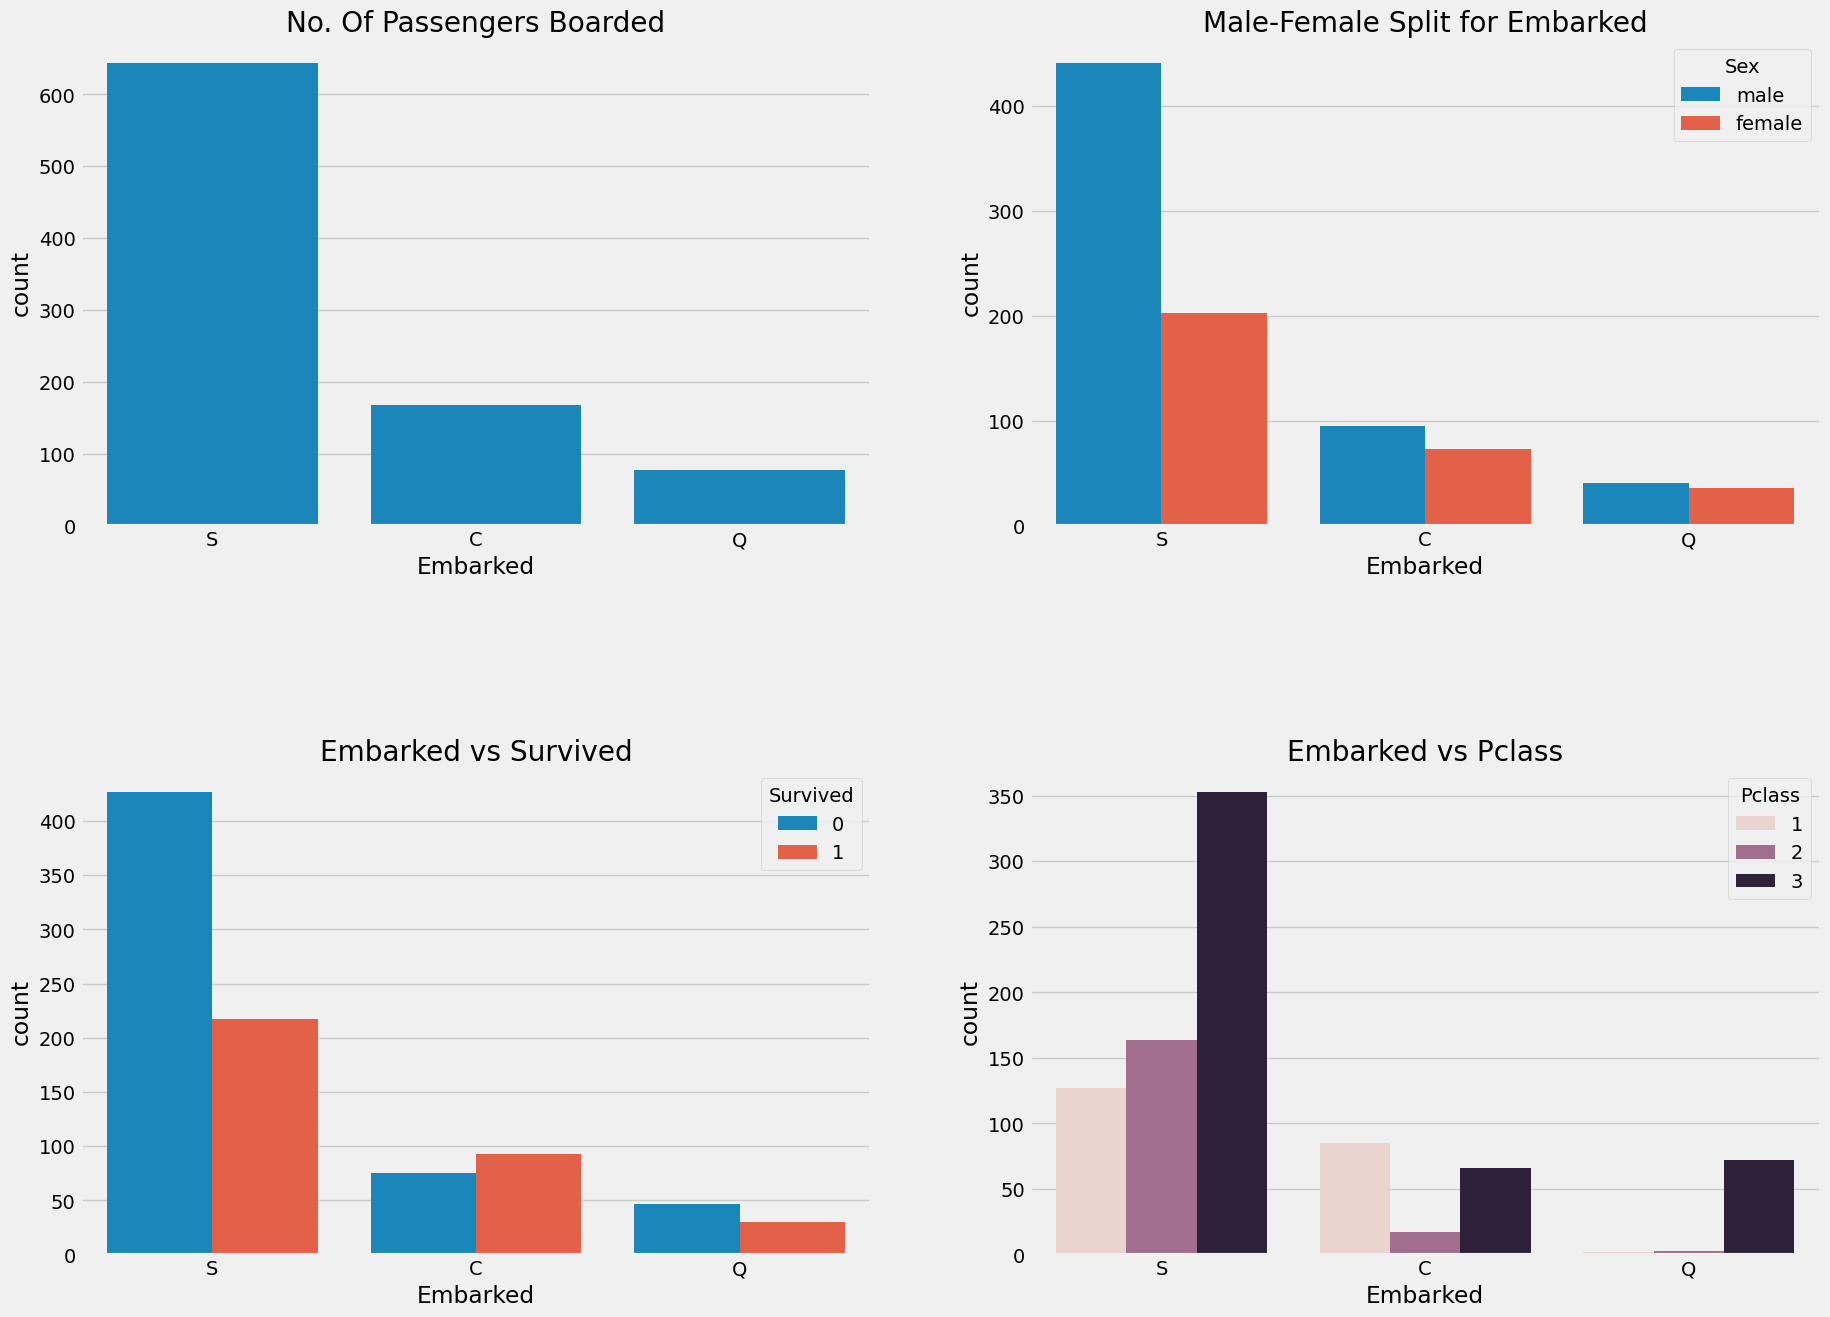

In [24]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot(x='Embarked',data=data,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot(x='Embarked',hue='Sex',data=data,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot(x='Embarked',hue='Survived',data=data,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot(x='Embarked',hue='Pclass',data=data,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

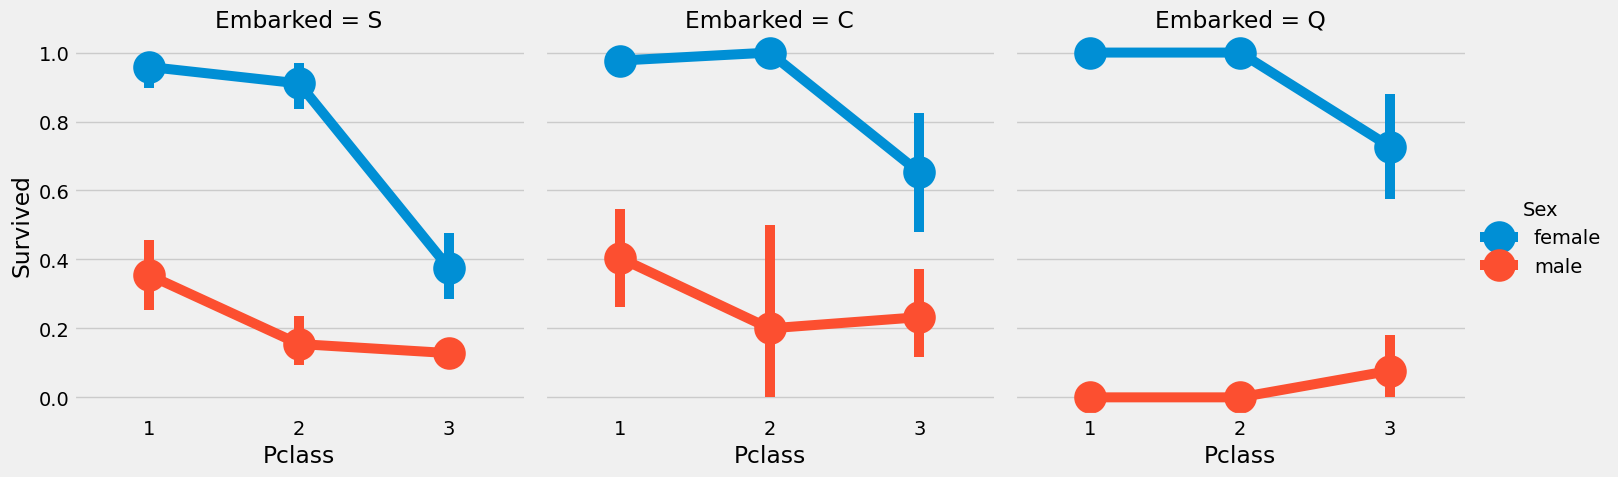

In [25]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',col='Embarked',data=data, kind='point')
plt.show()

#### Filling Embarked NaN

- Embarked 변수에 결측치(NaN)가 존재

- 가장 많은 승객이 S 항구에서 탑승했으므로 결측치 S로 대체

In [26]:
data['Embarked'].fillna('S',inplace=True)

In [27]:
data.Embarked.isnull().any()# Finally No NaN values

np.False_

### SibSip-->Discrete Feature

In [28]:
pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


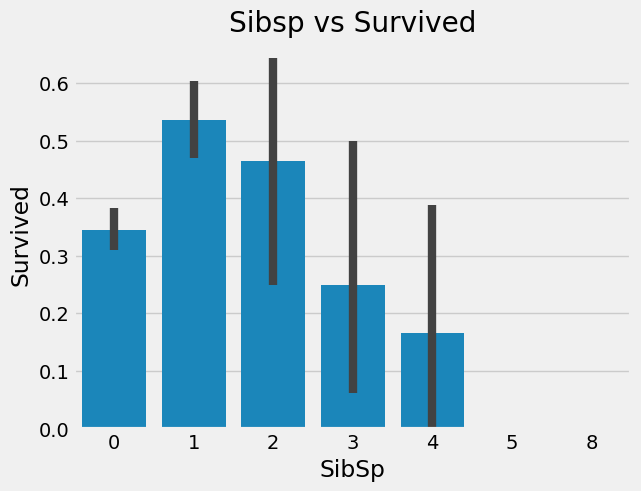

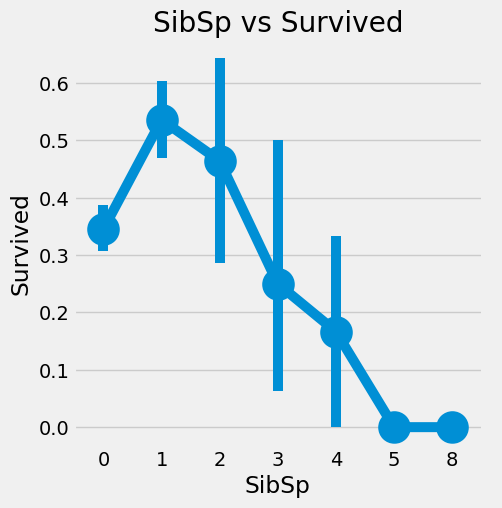

In [29]:
# catplot은 subplot이 Axes 위에 직접 그릴 수 없으므로 subplot 안에 직접 넣을 수 없음
sns.barplot(x='SibSp',y='Survived',data=data)
plt.title('Sibsp vs Survived')
sns.catplot(x='SibSp',y='Survived',data=data, kind='point')
plt.title('SibSp vs Survived')
plt.show()

In [30]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


- 형제·자매 수가 늘어날수록 생존률은 감소

-  대가족은 생존률이 0% -> 객실 등급(Pclass) 때문

- CrossTab :  SibSp(형제·자매+배우자 수)가 3 이상인 승객은 모두 3등석(Pclass3)에 속함 -> 3등석 대가족 모두 사망

## Parch

In [31]:
pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


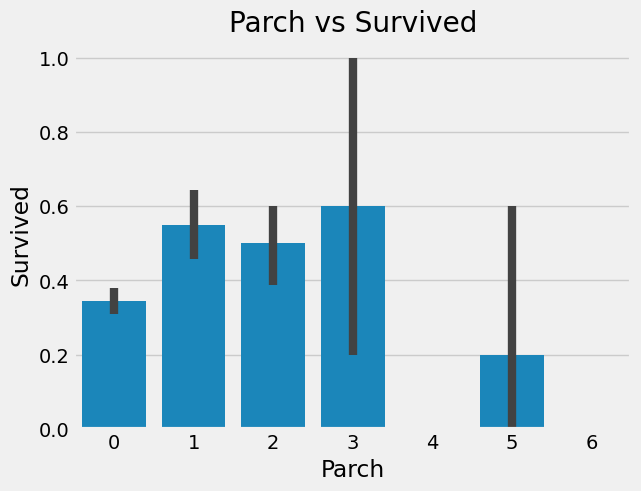

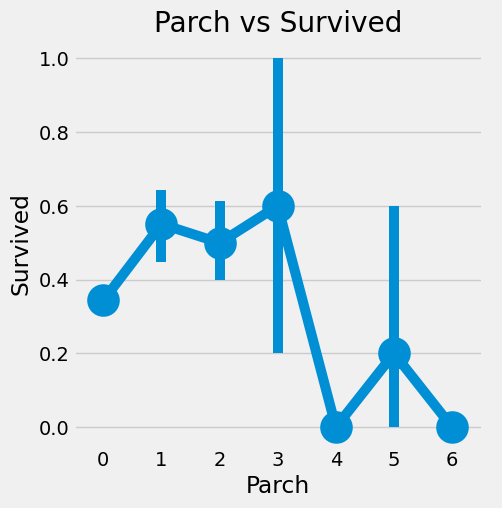

In [32]:
sns.barplot(x='Parch',y='Survived',data=data)
plt.title('Parch vs Survived')
sns.catplot(x='Parch',y='Survived',data=data, kind='point')
plt.title('Parch vs Survived')
plt.show()

## Fare--> Continous Feature

In [33]:
print('Highest Fare was:',data['Fare'].max())
print('Lowest Fare was:',data['Fare'].min())
print('Average Fare was:',data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


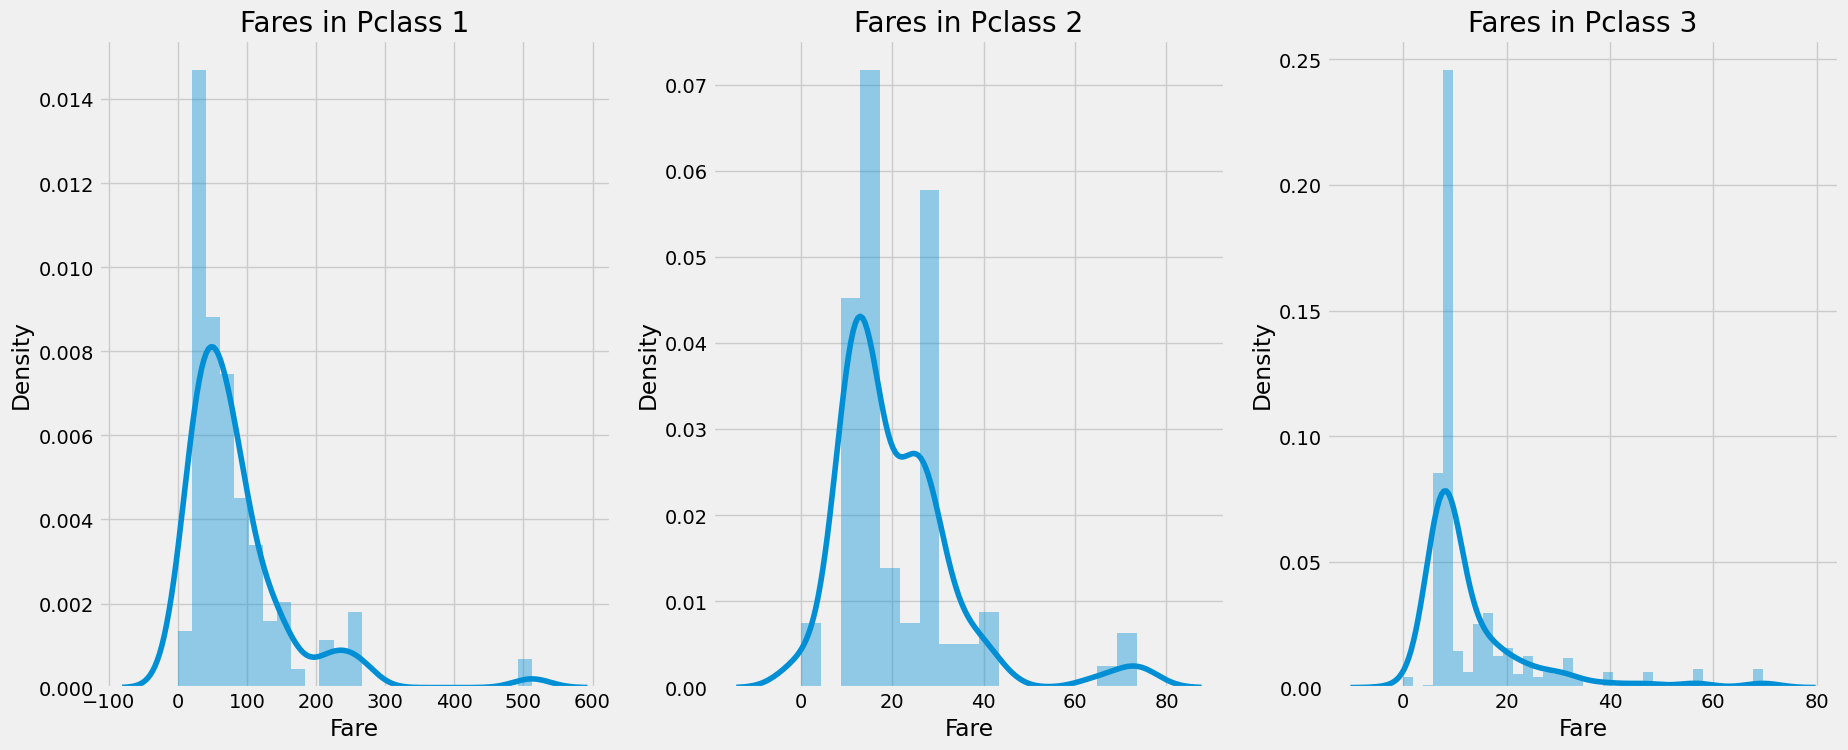

In [34]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(data[data['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(data[data['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(data[data['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
plt.show()

## Observations in a Nutshell for all features:

- Sex : 여성의 생존 확률이 남성보다 훨씬 높음

- Pclass :  1등석 승객은 생존 확률이 높고, 3등석은 매우 낮음. 특히 여성은 1등석에서 거의 모두 생존했고 2등석에서도 높은 생존률을 보임

- Age : 5 ~ 10세 이하 어린이는 생존 확률이 높았음. 반면 15~35세 승객은 사망자가 많았음

- Embarked : C 항구에서 탑승한 승객의 생존률이 상대적으로 높았음. S 항구는 1등석 승객이 많았지만, 3등석 승객의 대규모 사망으로 전체 생존률은 낮았음. Q 항구 승객은 거의 모두 3등석이었음

- Parch + SibSp(부모·자녀 + 형제·배우자) : 가족이 1 ~ 2명(형제·배우자) 또는 1~3명(부모·자녀)일 때 생존 확률이 높았음. 반대로 혼자 있거나 대가족으로 탑승한 경우 생존률이 낮았음




## Correlation Between The Features

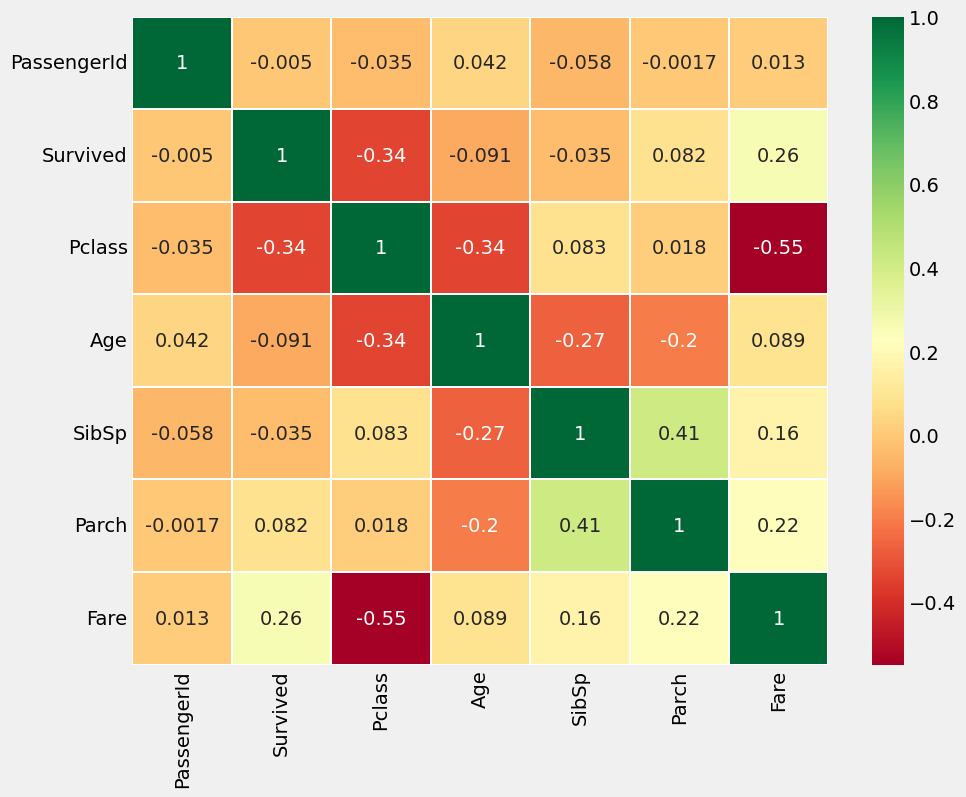

In [35]:
cols = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
sns.heatmap(data[cols].corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

### Interpreting The Heatmap

- 숫자형 변수만 비교한다. (문자열은 상관관계를 계산할 수 없음)

- 양의 상관관계(Positive Correlation): A가 증가하면 B도 증가 → 값이 1이면 완벽한 양의 상관관계.

- 음의 상관관계(Negative Correlation): A가 증가하면 B는 감소 → 값이 -1이면 완벽한 음의 상관관계.

- 두 변수가 완벽하게 상관관계가 있으면 사실상 같은 정보를 담고 있어 중복(다중공선성, MultiColinearity) 문제가 발생

- 모델 학습 시에는 이런 중복된 변수는 제거하는 것이 효율적

Heatmap 결과 :
- 전체적으로 변수들 간의 상관관계는 크지 않았음

- 가장 높은 상관관계는 SibSp와 Parch (0.41)

- 따라서 모든 변수를 그대로 사용할 수 있음





# Part2: Feature Engineering and Data Cleaning

- Feature Engineering : 주어진 데이터에서 불필요한 변수는 제거하고 새로운 변수를 만들어내는 과정

  ex. Name에서 호칭(Initials)을 추출하여 새로운 Feature 생성


## Age_band

Age는 연속형 변수라서 모델링에 직접 쓰기 어려움 -> Binning(구간화) 또는 Normalization 사용



**Binning**
- 최대 나이가 80세였으므로, 0~80 범위를 5개의 구간으로 나눔

- 즉, 80 ÷ 5 = 16 → 구간 크기 16.

- 따라서 나이를 16살 단위로 묶어 범주형 변수로 변환

In [36]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [37]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')#checking the number of passenegers in each band

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


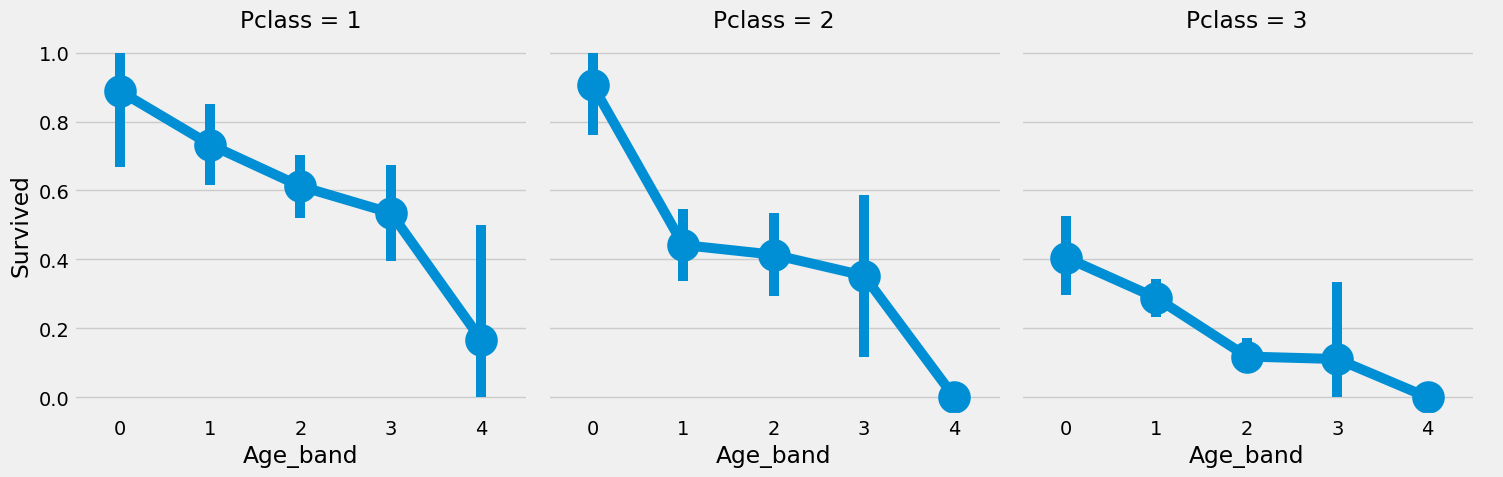

In [38]:
sns.catplot(x='Age_band',y='Survived',data=data, col='Pclass', kind='point')
plt.show()

## Family_Size and Alone

새로운 Feature 생성

- Family_size: Parch + SibSp (부모·자녀 수 + 형제·배우자 수) → 가족 규모를 나타내는 변수

- Alone: 승객이 혼자인지 여부를 나타내는 변수

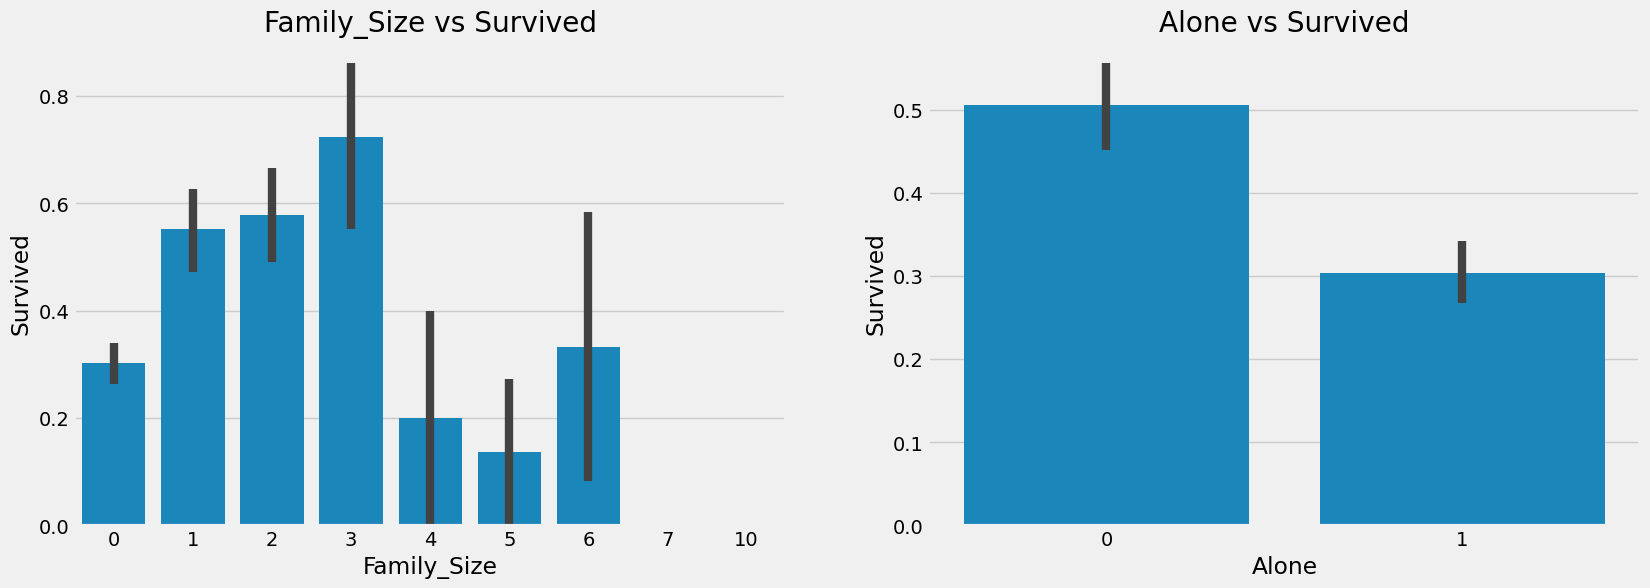

In [39]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']#family size
data['Alone']=0
data.loc[data.Family_Size==0,'Alone']=1#Alone

f,ax=plt.subplots(1,2,figsize=(18,6))
sns.barplot(x='Family_Size',y='Survived',data=data,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.barplot(x='Alone',y='Survived',data=data,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()


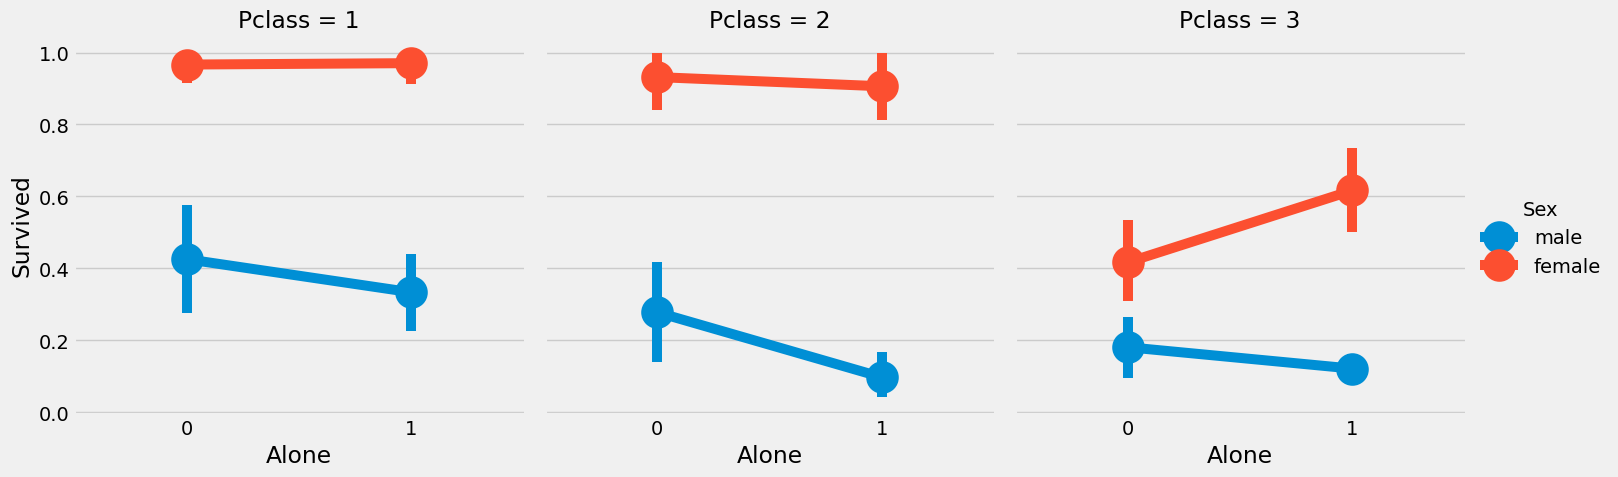

In [40]:
sns.catplot(x='Alone',y='Survived',data=data,hue='Sex',col='Pclass', kind='point')
plt.show()

## Fare_Range

Fare_Range 변수 생성

- 요금(Fare) 역시 연속형 변수이므로 순서형(Ordinal) 값으로 변환

- 이를 위해 pandas.qcut을 사용

- qcut은 지정한 구간(bin) 수에 따라 데이터를 나누어 값들을 동일한 개수로 분할된 구간에 배치

  ex. 5개의 bin을 지정하면 요금 데이터를 5개의 범위로 나누어 각각에 값을 할당함

In [41]:
data['Fare_Range']=pd.qcut(data['Fare'],4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


In [42]:
data['Fare_cat']=0
data.loc[data['Fare']<=7.91,'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_cat']=3

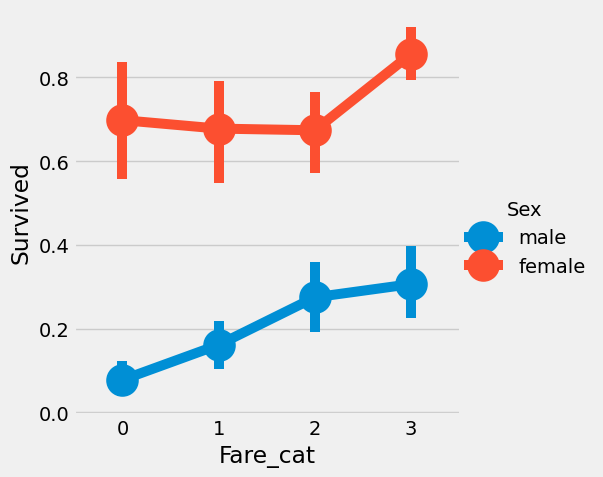

In [43]:
sns.catplot(x='Fare_cat',y='Survived',data=data,hue='Sex', kind='point')
plt.show()

## Converting String Values into Numeric

- 머신러닝 모델은 문자열 데이터를 직접 처리할 수 없기 때문에 Sex(성별), Embarked(승선 항구) 같은 문자열 변수들을 숫자형 값으로 변환해야 함



In [44]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

### Dropping UnNeeded Features

- Name : 범주형 값으로 변환할 수 없으므로 불필요

- Age : 이미 Age_band라는 파생 변수를 만들었으므로 원래 Age는 필요없음

- Ticket : 임의의 문자열로 범주화할 수 없으므로 제거

- Fare : 이미 Fare_cat 변수를 만들었으므로 원래 Fare는 필요없음

- Cabin : NaN 값이 많고, 여러 Cabin을 가진 승객도 있어 활용하기 어려움 → 제거

- Fare_Range : Fare_cat으로 대체했으므로 불필요

- PassengerId : 범주화할 수 없는 단순 식별자이므로 제거


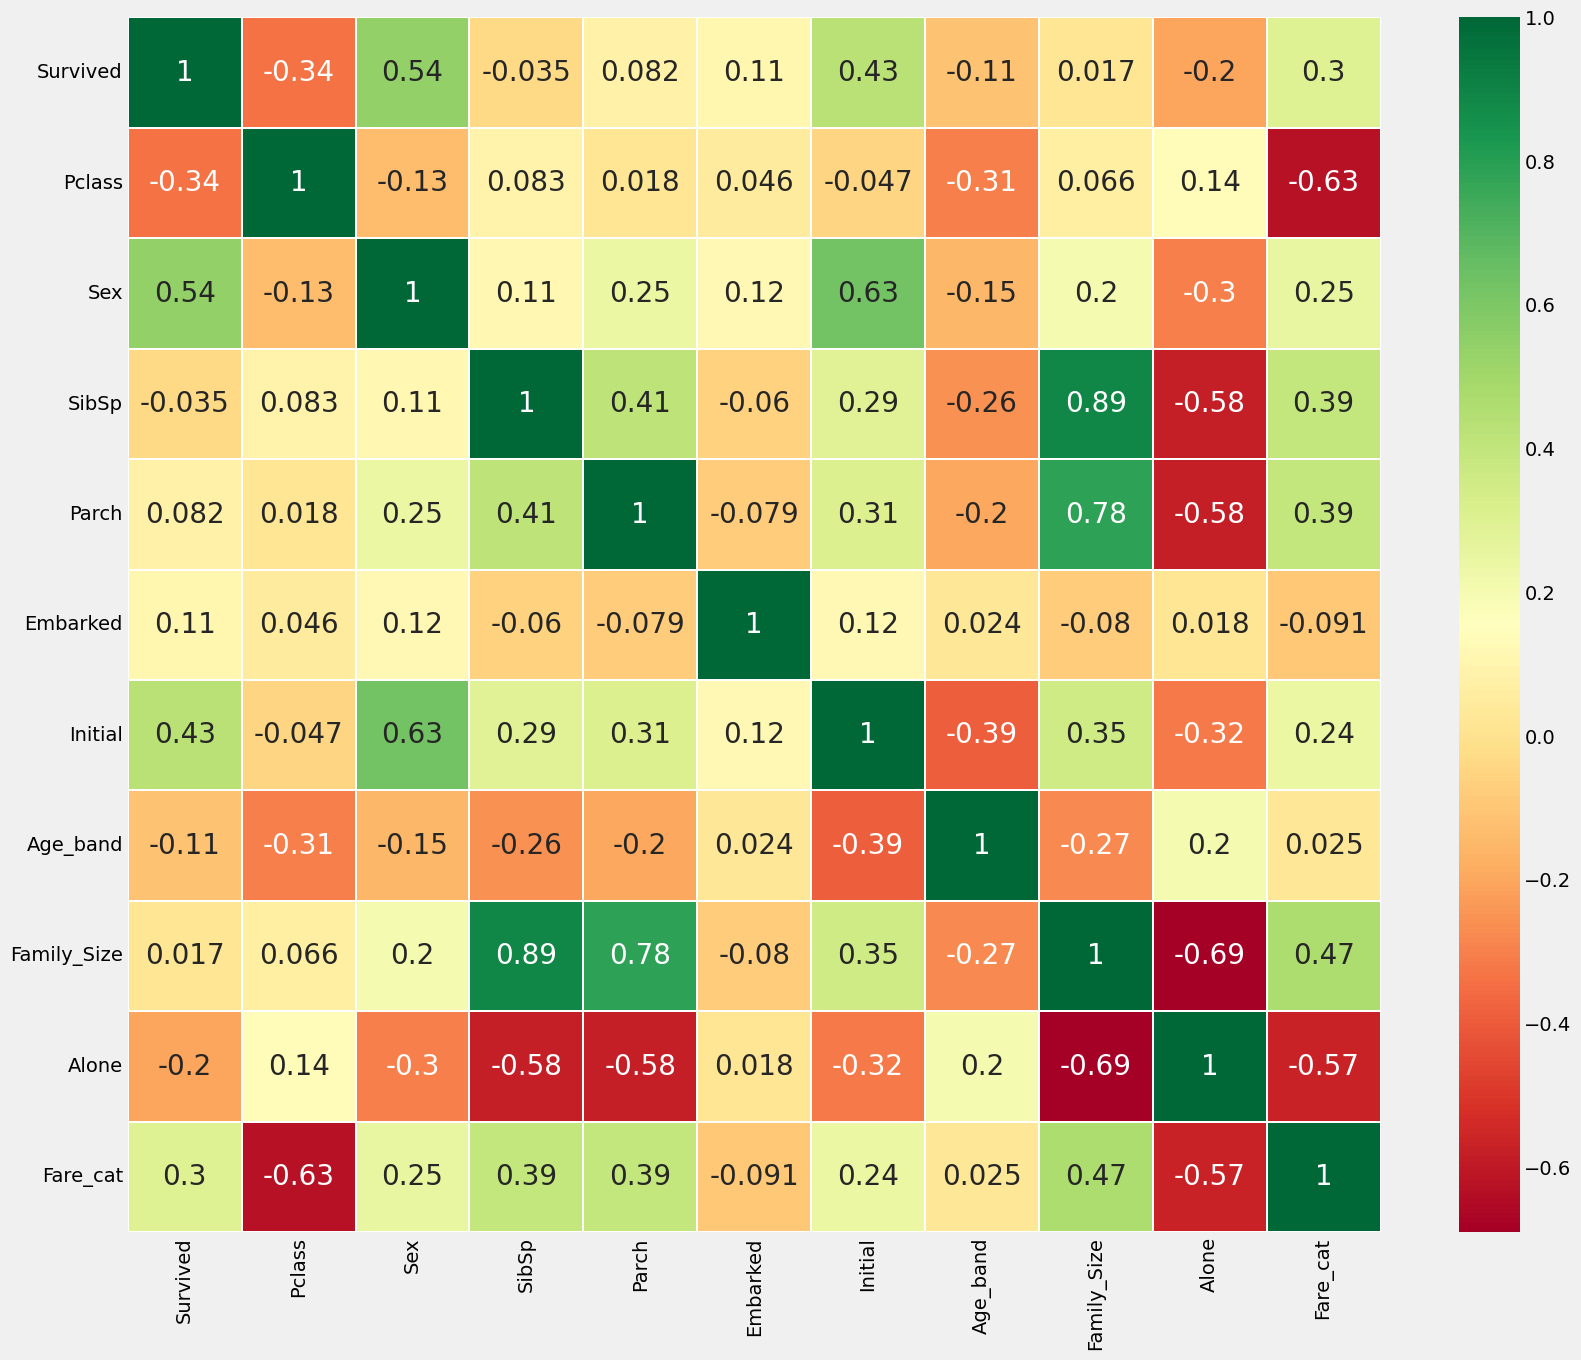

In [45]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Part3: Predictive Modeling

DA(탐색적 데이터 분석)로 여러 인사이트를 얻었지만, 이것만으로는 승객이 생존할지 사망할지를 정확히 예측할 수 없음

→ 분류(Classification) 알고리즘을 활용해 예측 모델을 만들어야 함

In [46]:
#importing all the required ML packages
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn import svm #support vector Machine
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.model_selection import train_test_split #training and testing data split
from sklearn import metrics #accuracy measure
from sklearn.metrics import confusion_matrix #for confusion matrix

In [47]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['Survived'])
train_X=train[train.columns[1:]]
train_Y=train[train.columns[:1]]
test_X=test[test.columns[1:]]
test_Y=test[test.columns[:1]]
X=data[data.columns[1:]]
Y=data['Survived']

## Radial Support Vector Machines(rbf-SVM)

In [48]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X,train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ',metrics.accuracy_score(prediction1,test_Y))

Accuracy for rbf SVM is  0.835820895522388


## Linear Support Vector Machine(linear-SVM)

In [49]:
model=svm.SVC(kernel='linear',C=0.1,gamma=0.1)
model.fit(train_X,train_Y)
prediction2=model.predict(test_X)
print('Accuracy for linear SVM is',metrics.accuracy_score(prediction2,test_Y))

Accuracy for linear SVM is 0.8171641791044776


## Logistic Regression

In [50]:
model = LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction3,test_Y))

The accuracy of the Logistic Regression is 0.8134328358208955


## Decision Tree

In [51]:
model=DecisionTreeClassifier()
model.fit(train_X,train_Y)
prediction4=model.predict(test_X)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction4,test_Y))

The accuracy of the Decision Tree is 0.7985074626865671


## K-Nearest Neighbours(KNN)

In [52]:
model=KNeighborsClassifier()
model.fit(train_X,train_Y)
prediction5=model.predict(test_X)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction5,test_Y))

The accuracy of the KNN is 0.8134328358208955


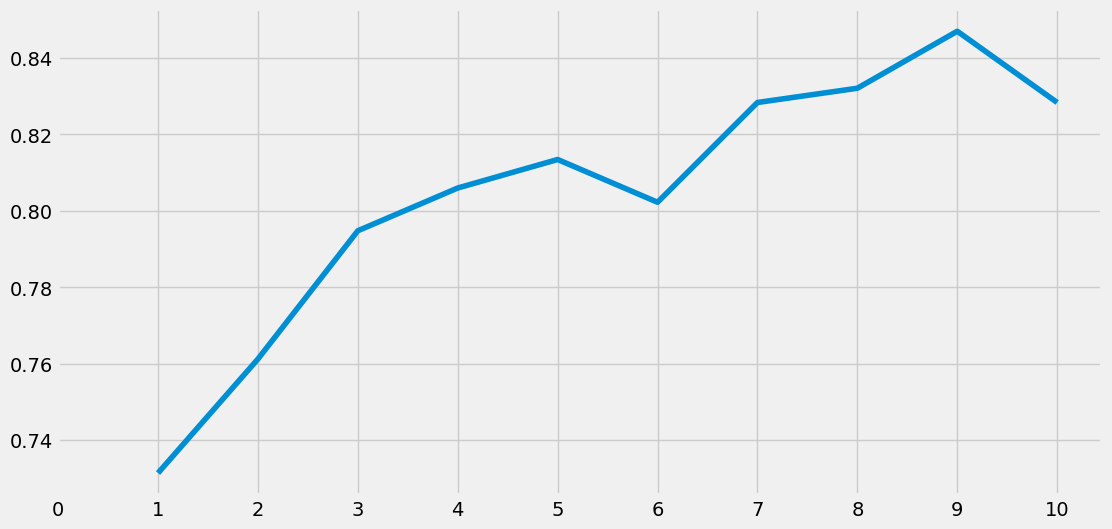

Accuracies for different values of n are: [0.73134328 0.76119403 0.79477612 0.80597015 0.81343284 0.80223881
 0.82835821 0.83208955 0.84701493 0.82835821] with the max value as  0.8470149253731343


In [53]:
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(train_X,train_Y)
    prediction=model.predict(test_X)
    a = pd.concat([a, pd.Series([metrics.accuracy_score(prediction, test_Y)])], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

## Gaussian Naive Bayes

In [54]:
model=GaussianNB()
model.fit(train_X,train_Y)
prediction6=model.predict(test_X)
print('The accuracy of the NaiveBayes is',metrics.accuracy_score(prediction6,test_Y))

The accuracy of the NaiveBayes is 0.8134328358208955


## Random Forests

In [55]:
model=RandomForestClassifier(n_estimators=100)
model.fit(train_X,train_Y)
prediction7=model.predict(test_X)
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction7,test_Y))

The accuracy of the Random Forests is 0.8171641791044776


- 모델 정확도(Accuracy)만으로는 분류기의 강건성(Robustness)을 판단할 수 없음

- 훈련·테스트 데이터가 바뀌면 정확도도 변함. 이는 모델 분산(Model Variance) 문제



# Cross Validation (교차 검증)

- 이를 극복하고 일반화된 모델을 얻기 위해 교차 검증을 사용

- 데이터가 불균형할 수 있는데 예를 들어 특정 클래스(ex.Class1)가 많고 다른 클래스는 적을 수 있음

- 따라서 알고리즘을 데이터셋의 모든 인스턴스에 대해 학습·테스트해야 하고 그 결과 정확도를 평균 내어 일반화된 성능을 얻음

### K-Fold Cross Validation

1) 데이터셋을 k개의 부분집합(subset)으로 나눔

2) 예를 들어 k=5라면, 5개의 부분으로 나누고 그중 1개를 테스트용으로 나머지 4개를 학습용으로 사용

3) 이 과정을 반복하면서 매번 다른 부분을 테스트용으로 사용

4) 각 반복에서 얻은 정확도와 오류를 평균 내어 최종 정확도를 계산

5) 이렇게 하면 특정 데이터셋에서 과소적합(Underfitting)이나 과적합(Overfitting) 문제를 줄이고, 더 일반화된 모델을 얻을 수 있음



In [56]:
from sklearn.model_selection import KFold #for K-fold cross validation
from sklearn.model_selection import cross_val_score #score evaluation
from sklearn.model_selection import cross_val_predict #prediction
kfold = KFold(n_splits=10, shuffle=True, random_state=22)
xyz=[]
accuracy=[]
std=[]
classifiers=['Linear Svm','Radial Svm','Logistic Regression','KNN','Decision Tree','Naive Bayes','Random Forest']
models=[svm.SVC(kernel='linear'),svm.SVC(kernel='rbf'),LogisticRegression(),KNeighborsClassifier(n_neighbors=9),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(n_estimators=100)]
for i in models:
    model = i
    cv_result = cross_val_score(model,X,Y, cv = kfold,scoring = "accuracy")
    cv_result=cv_result
    xyz.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)
new_models_dataframe2=pd.DataFrame({'CV Mean':xyz,'Std':std},index=classifiers)
new_models_dataframe2

,CV Mean,Std
Linear Svm,0.784607,0.057841
Radial Svm,0.828377,0.057096
Logistic Regression,0.799176,0.040154
KNN,0.808140,0.035630
Decision Tree,0.809226,0.042518
Naive Bayes,0.795843,0.054861
Random Forest,0.817091,0.040977


<Axes: >

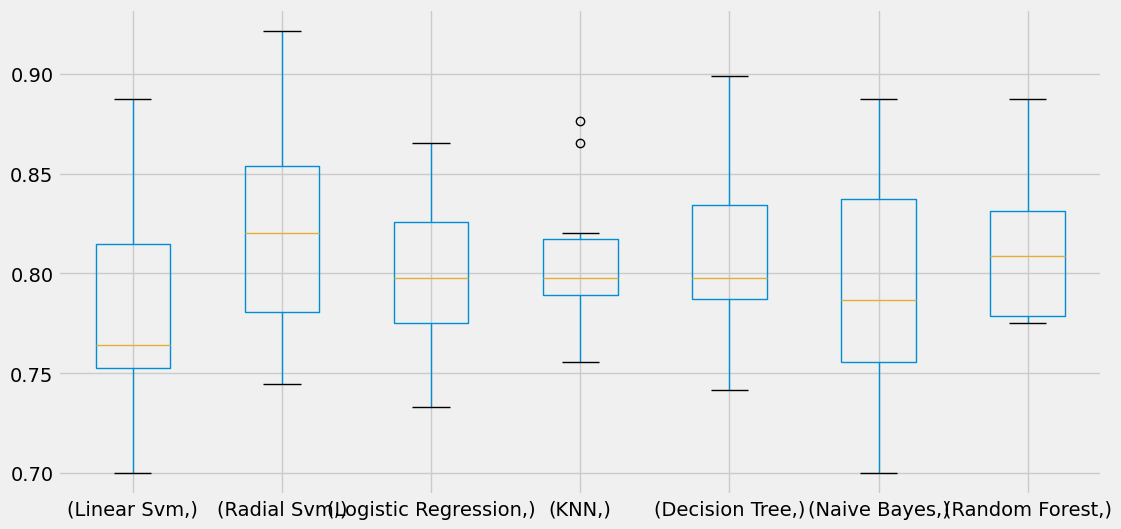

In [57]:
plt.subplots(figsize=(12,6))
box=pd.DataFrame(accuracy,index=[classifiers])
box.T.boxplot()

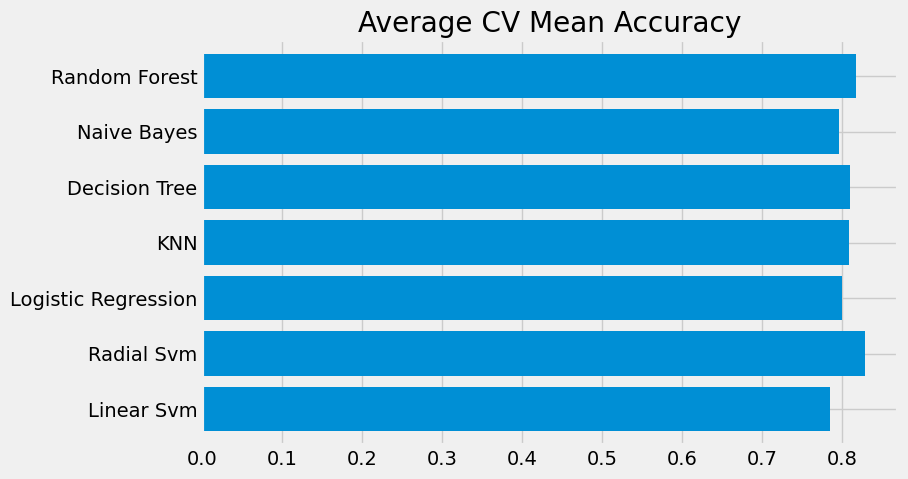

In [58]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig=plt.gcf()
fig.set_size_inches(8,5)
plt.show()

## Confusion Matrix

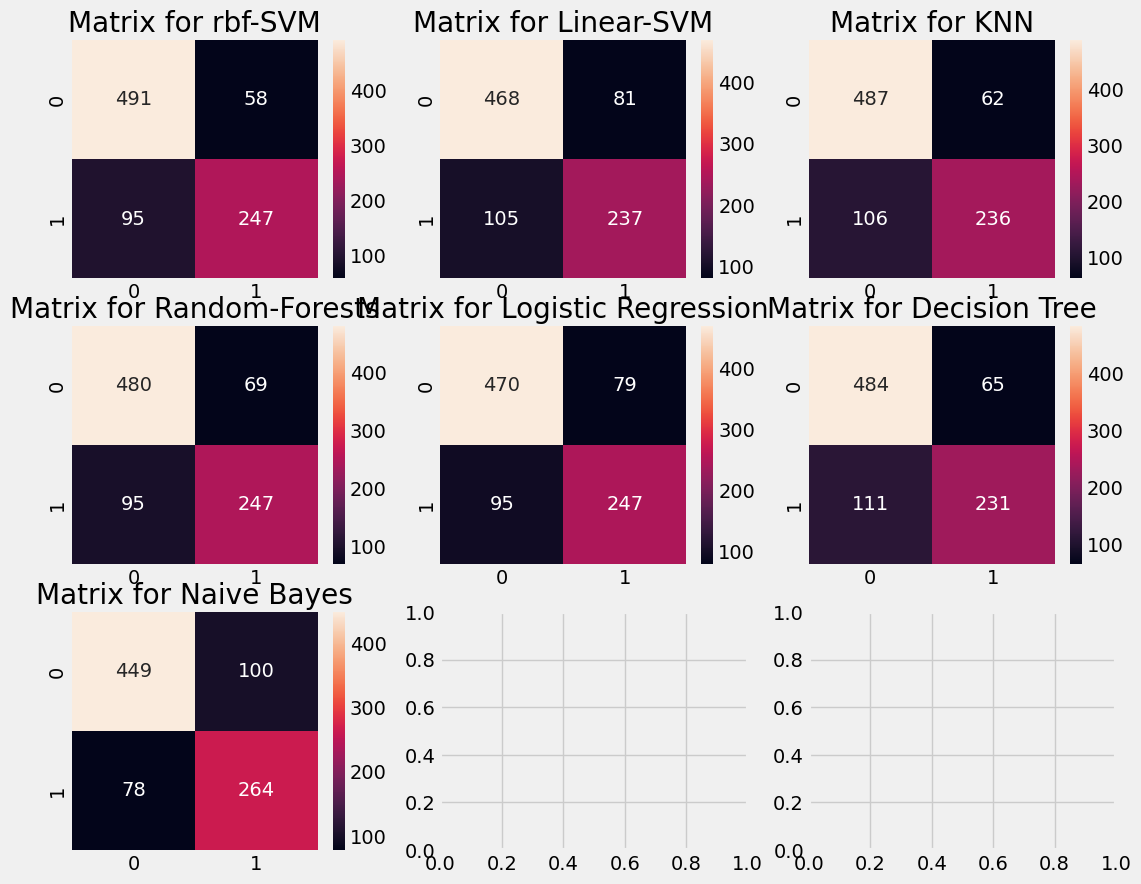

In [59]:
f,ax=plt.subplots(3,3,figsize=(12,10))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,0],annot=True,fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')
y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,1],annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')
y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=9),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,2],annot=True,fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')
y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,0],annot=True,fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')
y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,1],annot=True,fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')
y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,2],annot=True,fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')
y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[2,0],annot=True,fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

### Interpreting Confusion Matrix

- rbf-SVM → 사망자 예측 정확도가 높음.

- Naive Bayes → 생존자 예측 정확도가 더 높음.


### Hyper-Parameters Tuning
- 머신러닝 모델은 기본값을 가진 블랙박스와 같음 ex. SVM의 C, gamma 같은 값들은 모델의 학습 방식에 큰 영향을 줌

- 이런 값들을 조정하여 더 나은 성능을 얻는 과정을 하이퍼파라미터 튜닝

- 여기서는 가장 성능이 좋은 두 모델인 SVM과 Random Forest에 대해 튜닝을 진행


### SVM


In [60]:
from sklearn.model_selection import GridSearchCV
C=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
gamma=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
kernel=['rbf','linear']
hyper={'kernel':kernel,'C':C,'gamma':gamma}
gd=GridSearchCV(estimator=svm.SVC(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
0.8282593685267716
SVC(C=0.4, gamma=0.3)


### Random Forests

In [61]:
n_estimators=range(100,1000,100)
hyper={'n_estimators':n_estimators}
gd=GridSearchCV(estimator=RandomForestClassifier(random_state=0),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.819327098110602
RandomForestClassifier(n_estimators=300, random_state=0)


## Ensembling

- 앙상블(Ensembling)은 여러 개의 단순한 모델을 결합해 하나의 강력한 모델을 만드는 방법

- 쉽게 말해, 여러 사람에게 의견을 물어보고 종합해서 더 신뢰할 만한 결론을 내리는 것과 같음

- 이렇게 하면 모델의 안정성과 성능을 높일 수 있음


### Voting Classifier
- 가장 간단한 앙상블 방법

- 서로 다른 여러 머신러닝 모델의 예측 결과를 결합해 평균적인 예측을 만든다.

- 즉, 각 모델이 내린 예측을 "투표"로 모아 최종 결과를 결정


In [62]:
from sklearn.ensemble import VotingClassifier
ensemble_lin_rbf=VotingClassifier(estimators=[('KNN',KNeighborsClassifier(n_neighbors=10)),
                                              ('RBF',svm.SVC(probability=True,kernel='rbf',C=0.5,gamma=0.1)),
                                              ('RFor',RandomForestClassifier(n_estimators=500,random_state=0)),
                                              ('LR',LogisticRegression(C=0.05)),
                                              ('DT',DecisionTreeClassifier(random_state=0)),
                                              ('NB',GaussianNB()),
                                              ('svm',svm.SVC(kernel='linear',probability=True))
                                             ],
                       voting='soft').fit(train_X,train_Y)
print('The accuracy for ensembled model is:',ensemble_lin_rbf.score(test_X,test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y, cv = 10,scoring = "accuracy")
print('The cross validated score is',cross.mean())

The accuracy for ensembled model is: 0.8171641791044776
The cross validated score is 0.8249188514357053


### Bagging

- 배깅(Bagging)은 일반적인 앙상블 방법 중 하나

- 데이터셋을 여러 작은 부분으로 나누고, 동일한 분류기를 각각 적용한 뒤 예측값을 평균내어 최종 결과를 만듬

- 이렇게 평균을 내면 분산(Variance)이 줄어들어 모델이 더 안정적

- Voting Classifier와 달리, 배깅은 서로 다른 모델이 아니라 동일한 분류기(Classifier)를 사용


In [63]:
from sklearn.ensemble import BaggingClassifier
model=BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=3),random_state=0,n_estimators=700)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged KNN is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged KNN is:',result.mean())

The accuracy for bagged KNN is: 0.832089552238806
The cross validated score for bagged KNN is: 0.8104244694132333


Bagged DecisionTree

In [64]:
model=BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,n_estimators=100)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged Decision Tree is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged Decision Tree is:',result.mean())

The accuracy for bagged Decision Tree is: 0.8208955223880597
The cross validated score for bagged Decision Tree is: 0.8171410736579275


### Boosting

- 순차적으로 학습기를 학습시키는 앙상블 기법

- 약한 모델(Weak Learner)을 단계적으로 개선해 나가는 방식

동작 방식:

  1) 먼저 전체 데이터셋으로 모델을 학습

  2) 모델은 일부 인스턴스를 맞추고 일부는 틀림

  3) 다음 반복(iteration)에서는 틀린 인스턴스에 더 큰 가중치를 주어 학습

  4) 즉, 이전에 틀린 데이터를 더 잘 맞추도록 모델을 점진적으로 개선

  5) 이 과정을 반복하면서 새로운 분류기를 계속 추가하고, 정확도가 일정 수준에 도달할 때까지 이어짐

**AdaBoost (Adaptive Boosting)**
- AdaBoost는 대표적인 부스팅 알고리즘

- 기본 약한 학습기(Weak Learner)는 Decision Tree(의사결정나무)

- 하지만 기본 학습기를 다른 알고리즘으로 바꿀 수도 있음

- 즉, AdaBoost는 여러 약한 학습기를 순차적으로 결합해 강력한 예측 모델을 만듬

In [65]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.1)
result=cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:',result.mean())

The cross validated score for AdaBoost is: 0.8136828963795256


Stochastic Gradient Boosting

In [66]:
from sklearn.ensemble import GradientBoostingClassifier
grad=GradientBoostingClassifier(n_estimators=500,random_state=0,learning_rate=0.1)
result=cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:',result.mean())

The cross validated score for Gradient Boosting is: 0.8115230961298376


XGBoost

In [67]:
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

The cross validated score for XGBoost is: 0.8182771535580524


Hyper-Parameter Tuning for AdaBoost

In [68]:
n_estimators=list(range(100,1100,100))
learn_rate=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
hyper={'n_estimators':n_estimators,'learning_rate':learn_rate}
gd=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.8293892411022534
AdaBoostClassifier(learning_rate=0.4, n_estimators=800)


### Confusion Matrix for the Best Model

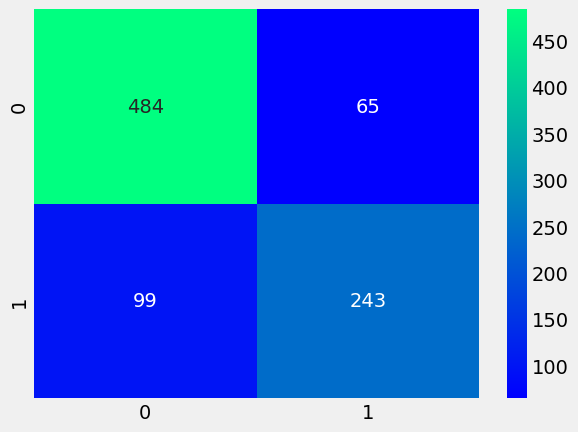

In [69]:
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.05)
result=cross_val_predict(ada,X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,result),cmap='winter',annot=True,fmt='2.0f')
plt.show()

## Feature Importance

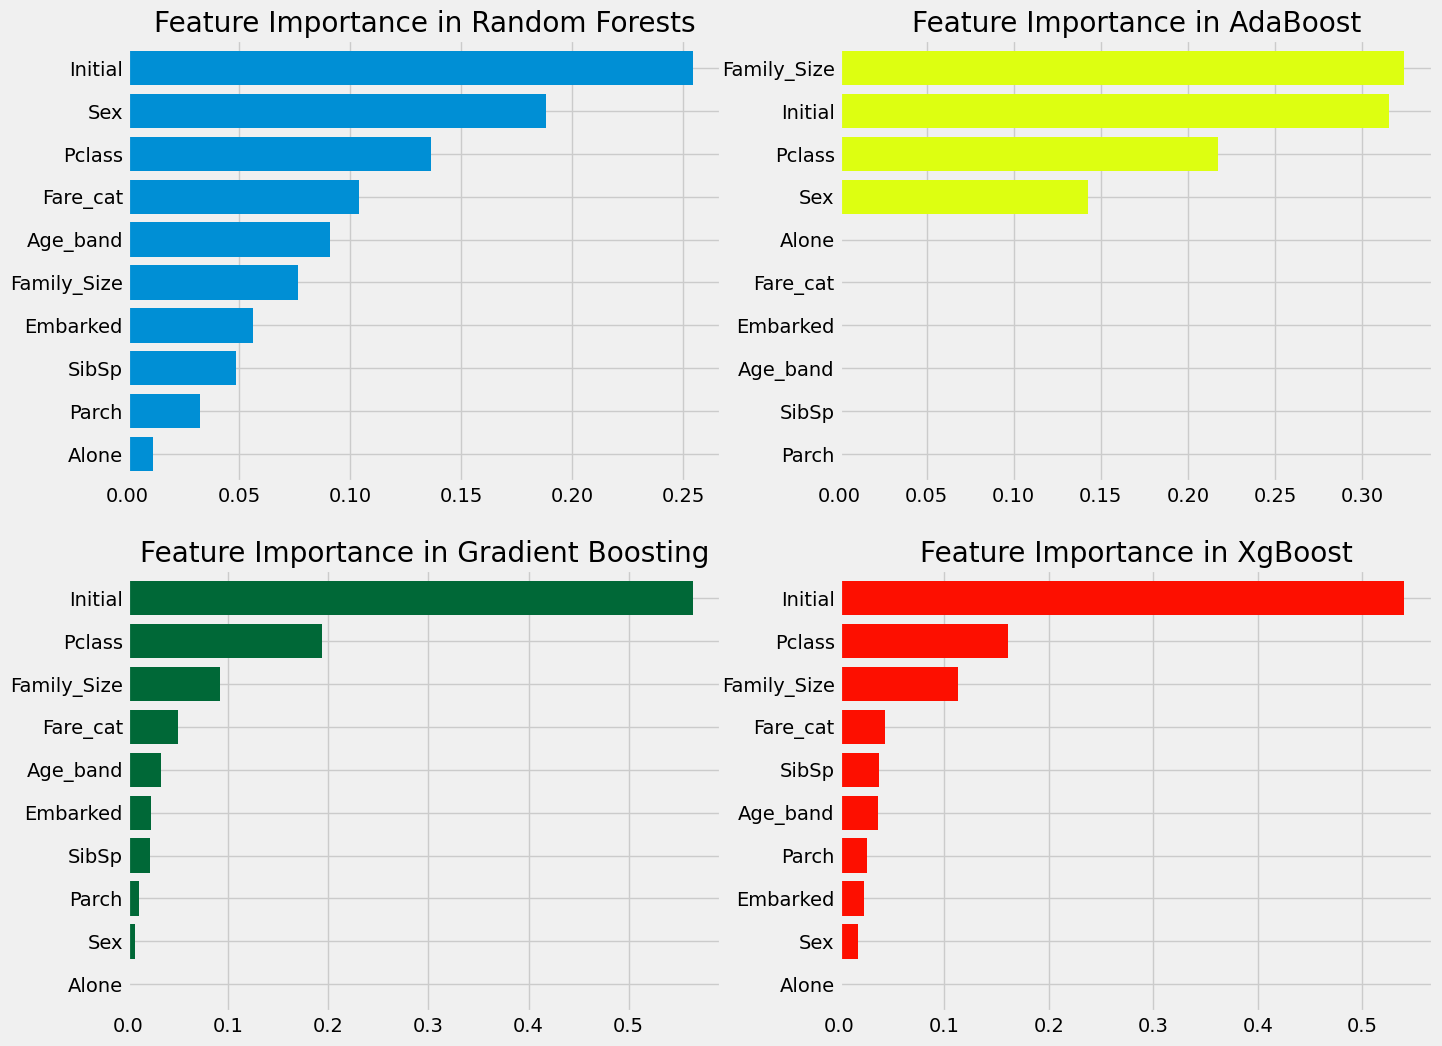

In [70]:
f,ax=plt.subplots(2,2,figsize=(15,12))
model=RandomForestClassifier(n_estimators=500,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,0])
ax[0,0].set_title('Feature Importance in Random Forests')
model=AdaBoostClassifier(n_estimators=200,learning_rate=0.05,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,1],color='#ddff11')
ax[0,1].set_title('Feature Importance in AdaBoost')
model=GradientBoostingClassifier(n_estimators=500,learning_rate=0.1,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,0],cmap='RdYlGn_r')
ax[1,0].set_title('Feature Importance in Gradient Boosting')
model=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,1],color='#FD0F00')
ax[1,1].set_title('Feature Importance in XgBoost')
plt.show()

중요한 Feature들

- 여러 분류기(Random Forests, AdaBoost 등)에서 공통적으로 중요한 변수는 Initial, Fare_cat, Pclass, Family_Size였다.

- Sex(성별)은 의외로 중요도가 낮게 나타났다. 다만 Random Forest에서는 성별이 중요한 변수로 나타났다.

- Initial은 여러 분류기에서 가장 중요한 변수로 나타났으며, 이미 성별(Sex)과 Initial 사이에 양의 상관관계가 있음을 확인했으므로 사실상 둘 다 성별을 나타내는 변수다.

- Pclass와 Fare_cat은 승객의 사회적·경제적 지위를 반영하고, Family_Size, Alone, Parch, SibSp는 가족 규모와 관련된 변수다.

즉, 다양한 분류기에서 중요한 Feature들을 비교해보면 성별·객실 등급·요금·가족 규모가 생존 여부를 결정하는 핵심 요인임을 다시 확인할 수 있다.